<a href="https://colab.research.google.com/github/YRMESHRAM/Machine-Vision-Practical/blob/main/MV_P2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

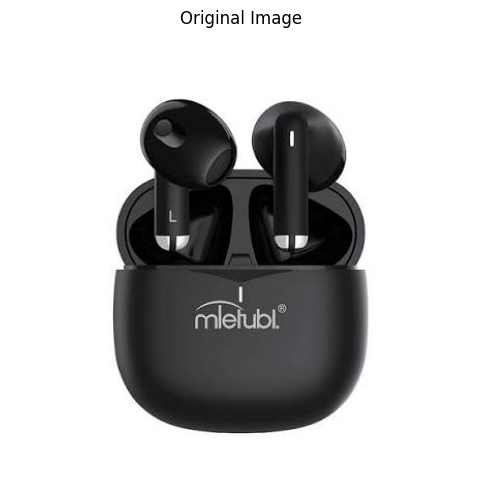

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Load the image
filename = '/content/TWS.jpg'
image = cv2.imread(filename)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {filename}")
else:
    # Convert the image from BGR to RGB for displaying with Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the original image
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

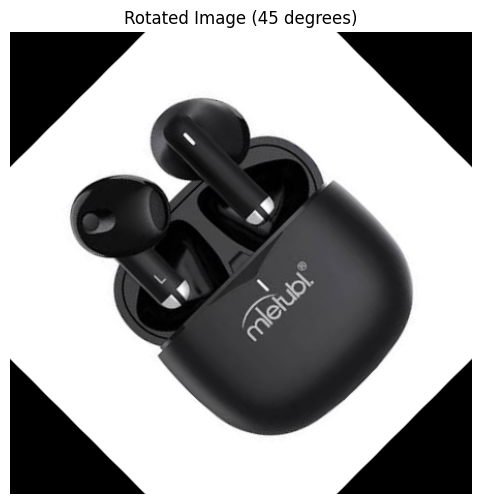

In [ ]:
# Get image dimensions
(h, w) = image.shape[:2]
center = (w // 2, h // 2)

# Define rotation matrix (rotate 45 degrees counter-clockwise)
M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated_img = cv2.warpAffine(image, M, (w, h))

# Convert to RGB for displaying
rotated_rgb = cv2.cvtColor(rotated_img, cv2.COLOR_BGR2RGB)

# Display the rotated image
plt.figure(figsize=(8, 6))
plt.imshow(rotated_rgb)
plt.title('Rotated Image (45 degrees)')
plt.axis('off')
plt.show()

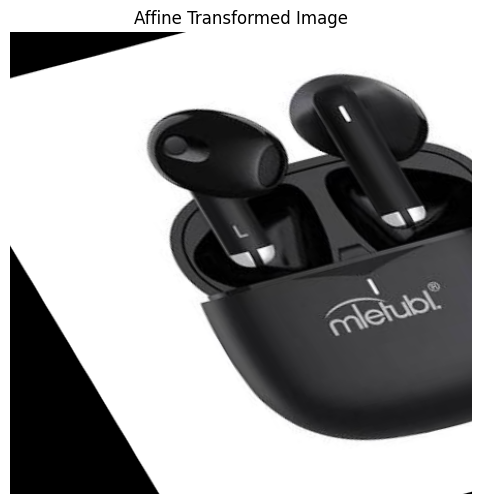

In [ ]:
# Define points for affine transformation
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

# Get the affine transformation matrix
M_affine = cv2.getAffineTransform(pts1, pts2)

# Apply the affine transformation
affine_img = cv2.warpAffine(image, M_affine, (w, h))

# Convert to RGB for displaying
affine_rgb = cv2.cvtColor(affine_img, cv2.COLOR_BGR2RGB)

# Display the affine transformed image
plt.figure(figsize=(8, 6))
plt.imshow(affine_rgb)
plt.title('Affine Transformed Image')
plt.axis('off')
plt.show()

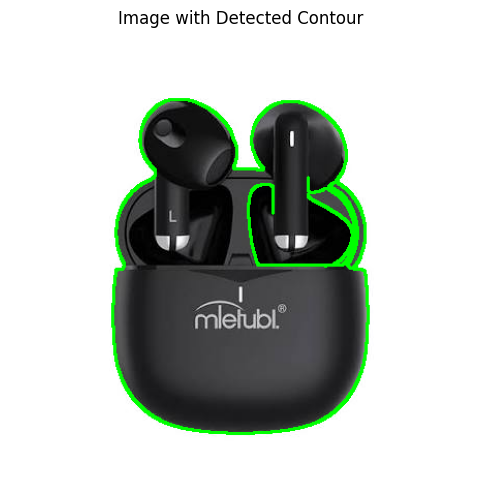

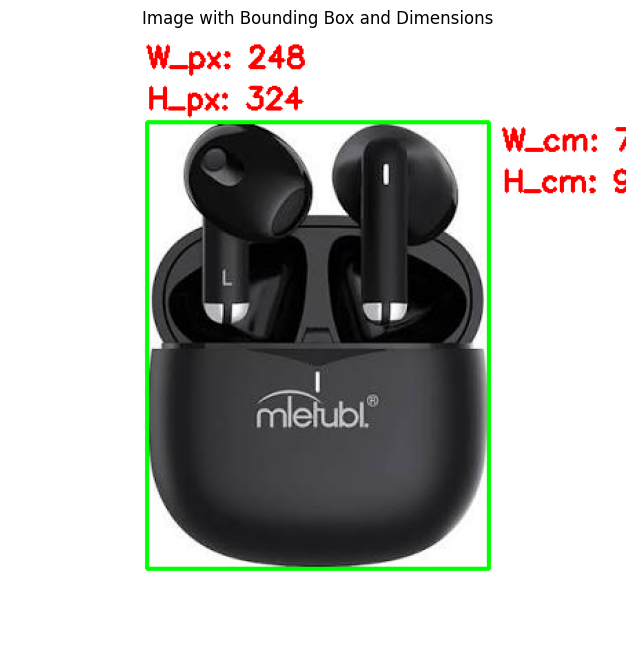

Detected object width in pixels: 248
Detected object height in pixels: 324
Pixels per cm (based on assumed width): 35.43
Estimated object width in cm: 7.00 cm
Estimated object height in cm: 9.15 cm


In [ ]:
# Convert the original image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise and improve edge detection
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply Canny edge detection
edged = cv2.Canny(blur, 50, 150)

# Find contours in the edged image
cnts, _ = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Sort contours by area in descending order and keep the largest one (assuming it's our object)
cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:1]

# Draw contours on a copy of the original image
output = image.copy()
cv2.drawContours(output, cnts, -1, (0, 255, 0), 2)

# Convert to RGB for displaying
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# Display the image with contours
plt.figure(figsize=(8, 6))
plt.imshow(output_rgb)
plt.title('Image with Detected Contour')
plt.axis('off')
plt.show()

# --- Perform measurements ---
# Assuming we have a reference object in the image with a known real-world dimension.
# For example, let's assume the largest contour represents the object and we know its width in real-world units.

# Get the bounding box of the largest contour
if cnts:
    x, y, w_pixels, h_pixels = cv2.boundingRect(cnts[0])

    # Display the bounding box
    measured_img = image.copy()
    cv2.rectangle(measured_img, (x, y), (x + w_pixels, y + h_pixels), (0, 255, 0), 2)

    # Assume a known reference dimension for conversion (e.g., a real object is 7 cm wide)
    # This 'pixels_per_cm' would ideally be calibrated from a known reference object in the image
    reference_real_width_cm = 7.0  # Example: assume the object is 7 cm wide

    # Calculate pixels per real-world unit (e.g., pixels per cm)
    pixels_per_cm = w_pixels / reference_real_width_cm

    # Estimate other dimensions using this ratio
    estimated_width_cm = w_pixels / pixels_per_cm
    estimated_height_cm = h_pixels / pixels_per_cm

    # Add dimensions text to the image
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.7
    font_thickness = 2
    text_color = (0, 0, 255) # Blue color for text

    # Pixel dimensions
    cv2.putText(measured_img, f"W_px: {w_pixels}", (x, y - 40), font, font_scale, text_color, font_thickness)
    cv2.putText(measured_img, f"H_px: {h_pixels}", (x, y - 10), font, font_scale, text_color, font_thickness)

    # Real-world dimensions
    cv2.putText(measured_img, f"W_cm: {estimated_width_cm:.2f} cm", (x + w_pixels + 10, y + 20), font, font_scale, text_color, font_thickness)
    cv2.putText(measured_img, f"H_cm: {estimated_height_cm:.2f} cm", (x + w_pixels + 10, y + 50), font, font_scale, text_color, font_thickness)

    # Convert to RGB for displaying
    measured_rgb = cv2.cvtColor(measured_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(measured_rgb)
    plt.title('Image with Bounding Box and Dimensions')
    plt.axis('off')
    plt.show()

    print(f"Detected object width in pixels: {w_pixels}")
    print(f"Detected object height in pixels: {h_pixels}")
    print(f"Pixels per cm (based on assumed width): {pixels_per_cm:.2f}")
    print(f"Estimated object width in cm: {estimated_width_cm:.2f} cm")
    print(f"Estimated object height in cm: {estimated_height_cm:.2f} cm")

else:
    print("No contours found to perform measurements.")